In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 200

# Variables del estudiante
promedio_parcial = np.random.uniform(50, 100, n)
asistencia = np.random.uniform(60, 100, n)
horas_estudio = np.random.uniform(1, 15, n)
accesos_moodle = np.random.randint(5, 60, n)
tareas = np.random.randint(2, 10, n)

# Calculamos calificación final y resultado
calificacion_final = (
    0.35 * promedio_parcial
    + 0.25 * asistencia
    + 1.5 * horas_estudio
    + 0.2 * accesos_moodle
    + 1.2 * tareas
    + np.random.normal(0, 3, n)
)
calificacion_final = np.clip(calificacion_final, 0, 100).round(2)
resultado = np.where(calificacion_final >= 70, "Aprueba", "Reprueba")

# Crear DataFrame y guardar en CSV
df = pd.DataFrame(
    {
        "Promedio_Parcial": promedio_parcial.round(2),
        "Asistencia": asistencia.round(2),
        "Horas_Estudio": horas_estudio.round(2),
        "Accesos_Moodle": accesos_moodle,
        "Tareas": tareas,
        "Calificacion_Final": calificacion_final,
        "Resultado": resultado,
    }
)

df.to_csv("alumnos.csv", index=False)
print("¡Listo! Se creó el archivo alumnos.csv")

¡Listo! Se creó el archivo alumnos.csv


--- MODELO BASE (Árbol de Decisión) ---
Accuracy: 0.8250

--- MODELO OPTIMIZADO (Random Forest) ---
Accuracy: 0.9000
Precision: 0.8400
Recall: 1.0000
F1 Score: 0.9130


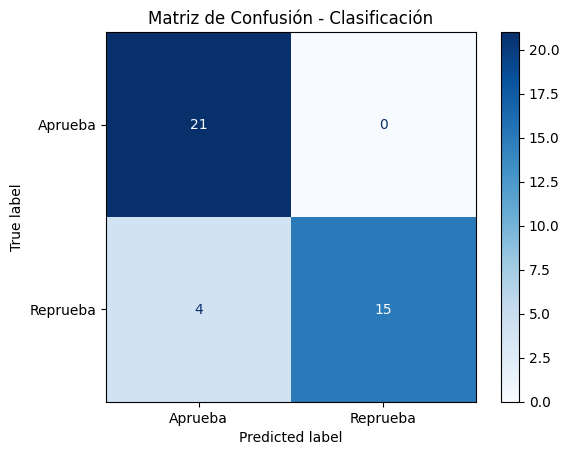

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Cargar archivo
df = pd.read_csv("alumnos.csv")

# 2. Separar variables
X = df[
    [
        "Promedio_Parcial",
        "Asistencia",
        "Horas_Estudio",
        "Accesos_Moodle",
        "Tareas",
    ]
]
y = df["Resultado"]

# 3. Train y Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Modelo Base: Árbol de Decisión
modelo_base = DecisionTreeClassifier(random_state=42)
modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)

print("--- MODELO BASE (Árbol de Decisión) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")

# 5. Modelo Optimizado: Random Forest
modelo_opt = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)
modelo_opt.fit(X_train, y_train)
y_pred_opt = modelo_opt.predict(X_test)

print("\n--- MODELO OPTIMIZADO (Random Forest) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(
    f"Precision: {precision_score(y_test, y_pred_opt, pos_label='Aprueba'):.4f}"
)
print(f"Recall: {recall_score(y_test, y_pred_opt, pos_label='Aprueba'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_opt, pos_label='Aprueba'):.4f}")

# Visualización
disp = ConfusionMatrixDisplay.from_estimator(
    modelo_opt, X_test, y_test, cmap=plt.cm.Blues
)
plt.title("Matriz de Confusión - Clasificación")
plt.savefig("graficas.png")
plt.show()

--- MODELO BASE (Regresión Lineal) ---
MAE: 2.3232
R2 Score: 0.9140

--- MODELO OPTIMIZADO (Random Forest) ---
MAE: 4.3159
MSE: 31.7672
RMSE: 5.6362
R2 Score: 0.7130


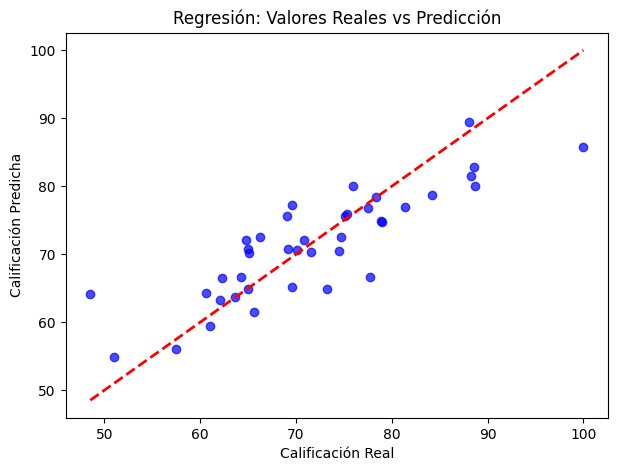

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Cargar datos
df = pd.read_csv("alumnos.csv")

# 2. Separar variables (Calificación Final como objetivo)
X = df[
    [
        "Promedio_Parcial",
        "Asistencia",
        "Horas_Estudio",
        "Accesos_Moodle",
        "Tareas",
    ]
]
y = df["Calificacion_Final"]

# 3. Train y Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Modelo Base: Regresión Lineal
reg_base = LinearRegression()
reg_base.fit(X_train, y_train)
y_pred_base = reg_base.predict(X_test)

print("--- MODELO BASE (Regresión Lineal) ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_base):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_base):.4f}")

# 5. Modelo Optimizado: Random Forest Regressor
reg_opt = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
reg_opt.fit(X_train, y_train)
y_pred_opt = reg_opt.predict(X_test)

print("\n--- MODELO OPTIMIZADO (Random Forest) ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_opt):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_opt):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_opt)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_opt):.4f}")

# Gráfica
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_opt, color="blue", alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2
)
plt.xlabel("Calificación Real")
plt.ylabel("Calificación Predicha")
plt.title("Regresión: Valores Reales vs Predicción")
plt.savefig("grafica_regresion.png")
plt.show()